#1.**Project Overview**

The AI Resume Screening System is a web-based recruitment solution that automates the initial resume screening process. The system compares an applicant's resume with a company's job description and calculates a match score using Natural Language Processing (NLP) techniques.

The company specifies:

Job title
Required skills
Priority (weight) for each skill
Minimum experience
Minimum qualification
Minimum acceptable ATS score

Applicants upload their resumes in PDF format. The system extracts the resume text, compares it with the job description using TF-IDF Vectorization and Cosine Similarity, applies weighted scoring based on the company's skill priorities, and determines whether the applicant is suitable for the job.

#2. **Problem Statement**

Recruiters often receive hundreds of resumes for a single job opening. Manually reviewing every resume is:

Time-consuming
Prone to human error
Difficult to scale
Inconsistent due to subjective judgment

A resume screening system can automate this process by ranking applicants according to how well their resumes match the job requirements.

#3. **Objectives**

The main objectives of this project are:

Develop an AI-based resume screening system.
Extract text from uploaded PDF resumes.
Compare resume content with a job description.
Calculate semantic similarity using TF-IDF and Cosine Similarity.
Apply company-defined priority weights to important skills.
Generate an ATS score for each applicant.
Classify applicants as Suitable or Not Suitable.
Integrate the scoring model with a Flask-based website.
#4.**Proposed Methodology**

The project follows these steps:

The company enters the job requirements.
The applicant uploads a resume.
The system extracts text from the resume.
The resume and job description are cleaned and preprocessed.
TF-IDF converts both texts into numerical vectors.
Cosine Similarity measures how closely the resume matches the job description.
The system checks which required skills are present and calculates a weighted skill score.
The final ATS score is computed.
The applicant is classified as Suitable or Not Suitable.

#5. **Workflow Diagram**
                 Company Portal
                       │
                       ▼
          Enter Job Description
          Enter Required Skills
          Set Skill Priorities
                       │
                       ▼
              Store Job Details
                       │
                       ▼
             Applicant Uploads Resume
                       │
                       ▼
            Extract Text from Resume
                       │
                       ▼
              Text Preprocessing
                       │
                       ▼
             TF-IDF Vectorization
                       │
                       ▼
             Cosine Similarity
                       │
                       ▼
          Weighted Skill Matching
                       │
                       ▼
            Final ATS Score
                       │
                       ▼
      Suitable / Not Suitable Decision
                       │
                       ▼
              Display Result
# 6. **Why TF-IDF and Cosine Similarity?**

This project uses TF-IDF (Term Frequency–Inverse Document Frequency) to convert textual data into numerical feature vectors.

Cosine Similarity is then used to measure the angle between the job description vector and the resume vector. A higher cosine similarity indicates that the resume is more relevant to the job description.

The final ATS score combines:

Semantic similarity between the resume and the job description.
Weighted skill matching based on company-defined priorities.

This approach is simple, efficient, interpretable, and well suited for a college-level AI and NLP project.

#Install & Import Libraries

In [ ]:
!pip install pdfplumber
!pip install scikit-learn
!pip install pandas
!pip install matplotlib
!pip install nltk

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.1/69.1 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 55.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 81.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 78.7 MB/s eta 0:00:00
  Attempting uninstall: Pillow
    Found existing installation: pillow 11.3.0
    Uninstalling pillow-11.3.0:
      Successfully uninstalled pillow-11.3.0


#Create the Dataset in Google Colab

In [ ]:
import pandas as pd

data = {
    "Resume": [
        "Python SQL Machine Learning Git Flask",
        "Java Spring Boot MySQL",
        "Python Django HTML CSS JavaScript",
        "C++ Embedded Systems Microcontrollers",
        "Python Pandas NumPy Machine Learning TensorFlow",
        "Java Android Kotlin",
        "Python SQL Power BI Excel",
        "C# ASP.NET SQL Server",
        "React Node.js MongoDB Express",
        "Python Flask Docker AWS Git",
        "HTML CSS Bootstrap",
        "Python OpenCV Deep Learning TensorFlow",
        "MATLAB Simulink",
        "Python SQL Git Linux",
        "PHP Laravel MySQL"
    ],

    "Job_Description": [
        "Python Developer SQL Machine Learning Git",
        "Python Developer SQL Machine Learning Git",
        "Full Stack Python Developer Django HTML CSS JavaScript",
        "Python Developer Flask SQL",
        "Data Scientist Python Pandas NumPy Machine Learning",
        "Data Scientist Python Machine Learning",
        "Data Analyst Python SQL Power BI",
        "Python Data Analyst SQL",
        "MERN Stack Developer",
        "Backend Python Developer Docker AWS",
        "Python Backend Developer",
        "Computer Vision Engineer Python Deep Learning",
        "Computer Vision Engineer",
        "Software Engineer Python SQL Git",
        "Python Software Engineer"
    ],

    "Suitable": [
        1,0,1,0,1,
        0,1,0,1,1,
        0,1,0,1,0
    ]
}

df = pd.DataFrame(data)

df

,Resume,Job_Description,Suitable
0,Python SQL Machine Learning Git Flask,Python Developer SQL Machine Learning Git,1
1,Java Spring Boot MySQL,Python Developer SQL Machine Learning Git,0
2,Python Django HTML CSS JavaScript,Full Stack Python Developer Django HTML CSS Ja...,1
3,C++ Embedded Systems Microcontrollers,Python Developer Flask SQL,0
4,Python Pandas NumPy Machine Learning TensorFlow,Data Scientist Python Pandas NumPy Machine Lea...,1
5,Java Android Kotlin,Data Scientist Python Machine Learning,0
6,Python SQL Power BI Excel,Data Analyst Python SQL Power BI,1
7,C# ASP.NET SQL Server,Python Data Analyst SQL,0
8,React Node.js MongoDB Express,MERN Stack Developer,1
9,Python Flask Docker AWS Git,Backend Python Developer Docker AWS,1


In [ ]:
df.to_csv("resume_dataset.csv", index=False)

In [ ]:
import pandas as pd

df = pd.read_csv("resume_dataset.csv")

df.head()

,Resume,Job_Description,Suitable
0,Python SQL Machine Learning Git Flask,Python Developer SQL Machine Learning Git,1
1,Java Spring Boot MySQL,Python Developer SQL Machine Learning Git,0
2,Python Django HTML CSS JavaScript,Full Stack Python Developer Django HTML CSS Ja...,1
3,C++ Embedded Systems Microcontrollers,Python Developer Flask SQL,0
4,Python Pandas NumPy Machine Learning TensorFlow,Data Scientist Python Pandas NumPy Machine Lea...,1


#Data Preprocessing
Explanation

Before comparing resumes with job descriptions, the text must be cleaned. Raw text often contains punctuation, uppercase letters, and common words (called stopwords) that do not add much meaning.

The preprocessing steps are:

Convert text to lowercase.
Remove punctuation and special characters.
Tokenize the text into individual words.
Remove English stopwords (e.g., "the", "is", "and").
Join the cleaned words back into a sentence.

This makes the text more consistent and improves the quality of the TF-IDF vectors.

#Install NLTK

In [ ]:
!pip install nltk

#Import Required Libraries

In [ ]:
import nltk
import string
import re

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

#Load Stopwords

In [ ]:
stop_words = set(stopwords.words('english'))

print("Number of Stopwords:", len(stop_words))

Number of Stopwords: 198


#Create the Preprocessing Function

In [ ]:
def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    # Tokenization
    words = word_tokenize(text)
    # Remove stopwords
    words = [word for word in words if word not in stop_words]
    # Join words
    cleaned_text = " ".join(words)
    return cleaned_text

#Apply Preprocessing to the Dataset

In [ ]:
import nltk
nltk.download('punkt_tab')
df["Clean_Resume"] = df["Resume"].apply(preprocess_text)
df["Clean_Job"] = df["Job_Description"].apply(preprocess_text)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


#View the Results

In [ ]:
df[["Resume", "Clean_Resume"]].head()

,Resume,Clean_Resume
0,Python SQL Machine Learning Git Flask,python sql machine learning git flask
1,Java Spring Boot MySQL,java spring boot mysql
2,Python Django HTML CSS JavaScript,python django html css javascript
3,C++ Embedded Systems Microcontrollers,c embedded systems microcontrollers
4,Python Pandas NumPy Machine Learning TensorFlow,python pandas numpy machine learning tensorflow


#Compare Original and Cleaned Text

In [ ]:
for i in range(3):
    print("Original Resume:")
    print(df["Resume"][i])
    print("\nClean Resume:")
    print(df["Clean_Resume"][i])
    print("\n-----------------------------\n")

Original Resume:
Python SQL Machine Learning Git Flask

Clean Resume:
python sql machine learning git flask

-----------------------------

Original Resume:
Java Spring Boot MySQL

Clean Resume:
java spring boot mysql

-----------------------------

Original Resume:
Python Django HTML CSS JavaScript

Clean Resume:
python django html css javascript

-----------------------------



#Feature Extraction using TF-IDF
**Explanation**

Computers cannot compare text directly. Therefore, we need to convert the resume and job description into numerical vectors.

TF-IDF (Term Frequency–Inverse Document Frequency) assigns a weight to each word:

Term Frequency (TF): Measures how often a word appears in a document.
Inverse Document Frequency (IDF): Reduces the weight of common words that appear in many documents.
Words that are important for a specific resume or job description receive higher weights.

This allows the model to compare documents mathematically.

#Import the TF-IDF Vectorizer

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

#Combine Resume and Job Description Text

We combine all resumes and job descriptions so that TF-IDF builds a common vocabulary.

In [ ]:
all_text = pd.concat([df["Clean_Resume"], df["Clean_Job"]])
print("Total Documents:", len(all_text))

Total Documents: 30


#Create the TF-IDF Vectorizer

In [ ]:
vectorizer = TfidfVectorizer()
vectorizer.fit(all_text)

TfidfVectorizer()

#Transform the Resume Text

In [ ]:
resume_vectors = vectorizer.transform(df["Clean_Resume"])

#Transform the Job Descriptions

In [ ]:
job_vectors = vectorizer.transform(df["Clean_Job"])

#Check the Shape of the Vectors

In [ ]:
print("Resume Vector Shape :", resume_vectors.shape)
print("Job Vector Shape    :", job_vectors.shape)

Resume Vector Shape : (15, 53)
Job Vector Shape    : (15, 53)


#Display the Vocabulary

In [ ]:
feature_names = vectorizer.get_feature_names_out()
print(feature_names)

['analyst' 'android' 'aspnet' 'aws' 'backend' 'bi' 'boot' 'bootstrap'
 'computer' 'css' 'data' 'deep' 'developer' 'django' 'docker' 'embedded'
 'engineer' 'excel' 'express' 'flask' 'full' 'git' 'html' 'java'
 'javascript' 'kotlin' 'laravel' 'learning' 'linux' 'machine' 'matlab'
 'mern' 'microcontrollers' 'mongodb' 'mysql' 'nodejs' 'numpy' 'opencv'
 'pandas' 'php' 'power' 'python' 'react' 'scientist' 'server' 'simulink'
 'software' 'spring' 'sql' 'stack' 'systems' 'tensorflow' 'vision']


#View the TF-IDF Matrix

In [ ]:
tfidf_df = pd.DataFrame(
    resume_vectors.toarray(),
    columns=feature_names
)
tfidf_df.head()

,analyst,android,aspnet,aws,backend,bi,boot,bootstrap,computer,css,...,scientist,server,simulink,software,spring,sql,stack,systems,tensorflow,vision
0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.355794,0.0,0.00000,0.000000,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.527784,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.527784,0.000000,0.0,0.00000,0.000000,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.466088,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.00000,0.000000,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.57735,0.000000,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.00000,0.489131,0.0


#Display TF-IDF Scores for the First Resume

In [ ]:
first_resume = tfidf_df.iloc[0]
important_words = first_resume[first_resume > 0].sort_values(ascending=False)
print(important_words)

flask       0.532565
git         0.434776
machine     0.434776
learning    0.390860
sql         0.355794
python      0.242800
Name: 0, dtype: float64


#Calculate Cosine Similarity
Explanation

After converting the resumes and job descriptions into TF-IDF vectors, we compare them using Cosine Similarity.

Cosine Similarity measures the angle between two vectors.

The similarity score ranges from:

1.0 → Perfect match (100%)
0.0 → No similarity

The formula is:

Cosine Similarity=
A⋅B/∣∣A∣∣×∣∣B∣∣

where:

A = Resume vector
B = Job Description vector

A higher similarity score means the resume is more relevant to the job.

#Import Cosine Similarity

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

#Calculate Similarity Score for Each Resume

In [ ]:
similarity_scores = []
for i in range(len(df)):
    score = cosine_similarity(
        resume_vectors[i],
        job_vectors[i]
    )[0][0]
    similarity_scores.append(score)

#Add Similarity Score to Dataset

In [ ]:
df["Cosine_Similarity"] = similarity_scores

#Convert Similarity to Percentage

In [ ]:
df["Similarity_Percentage"] = round(
    df["Cosine_Similarity"] * 100,
    2
)

#View Results

In [ ]:
df[[
    "Resume",
    "Job_Description",
    "Similarity_Percentage"
]]

,Resume,Job_Description,Similarity_Percentage
0,Python SQL Machine Learning Git Flask,Python Developer SQL Machine Learning Git,76.12
1,Java Spring Boot MySQL,Python Developer SQL Machine Learning Git,0.00
2,Python Django HTML CSS JavaScript,Full Stack Python Developer Django HTML CSS Ja...,76.31
3,C++ Embedded Systems Microcontrollers,Python Developer Flask SQL,0.00
4,Python Pandas NumPy Machine Learning TensorFlow,Data Scientist Python Pandas NumPy Machine Lea...,70.28
5,Java Android Kotlin,Data Scientist Python Machine Learning,0.00
6,Python SQL Power BI Excel,Data Analyst Python SQL Power BI,63.23
7,C# ASP.NET SQL Server,Python Data Analyst SQL,14.57
8,React Node.js MongoDB Express,MERN Stack Developer,0.00
9,Python Flask Docker AWS Git,Backend Python Developer Docker AWS,60.08


#Print Each Applicant's Score

In [ ]:
for i in range(len(df)):
    print(f"Applicant {i+1}")
    print("Similarity Score:",
          round(df['Similarity_Percentage'][i],2),
          "%")
    print("-"*40)

Applicant 1
Similarity Score: 76.12 %
----------------------------------------
Applicant 2
Similarity Score: 0.0 %
----------------------------------------
Applicant 3
Similarity Score: 76.31 %
----------------------------------------
Applicant 4
Similarity Score: 0.0 %
----------------------------------------
Applicant 5
Similarity Score: 70.28 %
----------------------------------------
Applicant 6
Similarity Score: 0.0 %
----------------------------------------
Applicant 7
Similarity Score: 63.23 %
----------------------------------------
Applicant 8
Similarity Score: 14.57 %
----------------------------------------
Applicant 9
Similarity Score: 0.0 %
----------------------------------------
Applicant 10
Similarity Score: 60.08 %
----------------------------------------
Applicant 11
Similarity Score: 0.0 %
----------------------------------------
Applicant 12
Similarity Score: 39.55 %
----------------------------------------
Applicant 13
Similarity Score: 0.0 %
----------------------

#Classify Applicants

In [ ]:
def classify(score):
    if score >= 50:
        return "Suitable"
    else:
        return "Not Suitable"
df["Prediction"] = df["Similarity_Percentage"].apply(classify)

#Display Final Results

In [ ]:
df[[
    "Similarity_Percentage",
    "Prediction"
]]

,Similarity_Percentage,Prediction
0,76.12,Suitable
1,0.00,Not Suitable
2,76.31,Suitable
3,0.00,Not Suitable
4,70.28,Suitable
5,0.00,Not Suitable
6,63.23,Suitable
7,14.57,Not Suitable
8,0.00,Not Suitable
9,60.08,Suitable


#Find the Best Matching Resume

In [ ]:
best_candidate = df.loc[
    df["Similarity_Percentage"].idxmax()
]
best_index = df["Similarity_Percentage"].idxmax()
print("Best Resume Match")
print("-------------------------")
print("Applicant Number :", best_index + 1)
print("Resume:")
print(best_candidate["Resume"])
print("\nJob Description:")
print(best_candidate["Job_Description"])
print("\nSimilarity Score:",
      best_candidate["Similarity_Percentage"],
      "%")

Best Resume Match
-------------------------
Applicant Number : 3
Resume:
Python Django HTML CSS JavaScript

Job Description:
Full Stack Python Developer Django HTML CSS JavaScript

Similarity Score: 76.31 %


#Visualize Similarity Scores

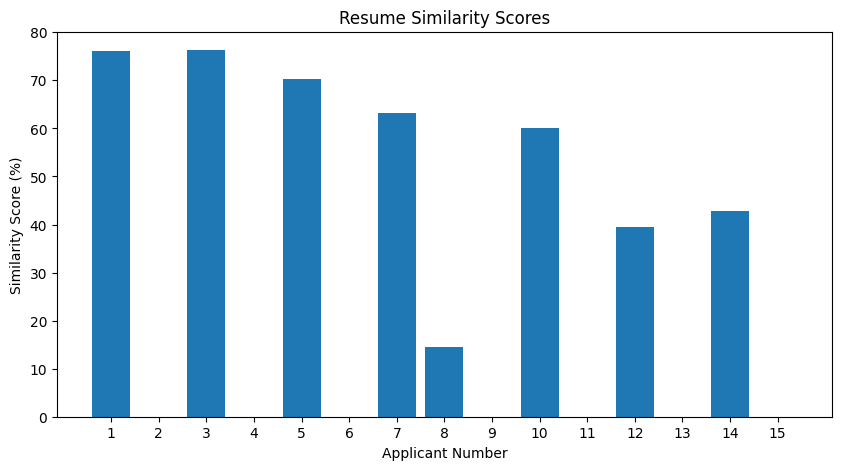

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.bar(
    range(len(df)),
    df["Similarity_Percentage"]
)
plt.xlabel("Applicant Number")
plt.ylabel("Similarity Score (%)")
plt.title("Resume Similarity Scores")
plt.xticks(range(len(df)), range(1, len(df)+1))
plt.show()

#Priority-Based Skill Matching
**Explanation**

Cosine Similarity compares the overall resume with the job description. However, companies often assign different importance to different skills.

**For example:**

Skill	Priority

Python	10

SQL	8

Machine Learning	10

Git	5

Docker	7

The system checks whether each required skill appears in the resume. If it does, the applicant earns the priority points for that skill.

The weighted skill score is calculated as:

Skill Score=
Obtained Priority×100/Total Priority
	​



#Define Required Skills and Priorities

In [ ]:
job_skills = {
    "python": 10,
    "sql": 8,
    "machine learning": 10,
    "git": 5,
    "docker": 7
}

#Calculate Skill Score

In [ ]:
skill_scores = []
for resume in df["Clean_Resume"]:
    obtained = 0
    total = sum(job_skills.values())
    for skill, priority in job_skills.items():
        if skill in resume:
            obtained += priority
    score = (obtained / total) * 100
    skill_scores.append(round(score, 2))

#Add Skill Score to the Dataset

In [ ]:
df["Skill_Score"] = skill_scores

#Display Skill Scores

In [ ]:
df[["Skill_Score"]]

,Skill_Score
0,82.5
1,20.0
2,25.0
3,0.0
4,50.0
5,0.0
6,45.0
7,20.0
8,0.0
9,55.0


#Final ATS Score

Now combine the Cosine Similarity and the Skill Score.

We will use:

70% weight for Cosine Similarity.
30% weight for Skill Score.

In [ ]:
df["ATS_Score"] = (
    0.7 * df["Similarity_Percentage"] +
    0.3 * df["Skill_Score"]
).round(2)

#Final Prediction

In [ ]:
def final_prediction(score):
    if score >= 50:
        return "Suitable"
    else:
        return "Not Suitable"
df["Final_Prediction"] = df["ATS_Score"].apply(final_prediction)

#Display Final Results

In [ ]:
df[[
    "Similarity_Percentage",
    "Skill_Score",
    "ATS_Score",
    "Final_Prediction"
]]

,Similarity_Percentage,Skill_Score,ATS_Score,Final_Prediction
0,76.12,82.5,78.03,Suitable
1,0.00,20.0,6.00,Not Suitable
2,76.31,25.0,60.92,Suitable
3,0.00,0.0,0.00,Not Suitable
4,70.28,50.0,64.20,Suitable
5,0.00,0.0,0.00,Not Suitable
6,63.23,45.0,57.76,Suitable
7,14.57,20.0,16.20,Not Suitable
8,0.00,0.0,0.00,Not Suitable
9,60.08,55.0,58.56,Suitable


#Find the Best Applicant Based on ATS Score

In [ ]:
best_index = df["ATS_Score"].idxmax()
print("Best Candidate")
print("-" * 30)
print("Applicant Number :", best_index + 1)
print("ATS Score        :", df.loc[best_index, "ATS_Score"], "%")
print("Prediction       :", df.loc[best_index, "Final_Prediction"])

Best Candidate
------------------------------
Applicant Number : 1
ATS Score        : 78.03 %
Prediction       : Suitable


#Final ATS Score
**Explanation**

The final ATS score is calculated by combining:

Cosine Similarity Score (70%) – Measures how closely the resume matches the job description.
Skill Score (30%) – Measures how many required skills the applicant has, considering their priority.

The formula is:

ATS Score=(0.7×Similarity Percentage)+(0.3×Skill Score)

This gives more importance to the overall semantic similarity while still rewarding applicants who possess the required high-priority skills.

In [ ]:
df["ATS_Score"] = (
    (0.7 * df["Similarity_Percentage"]) +
    (0.3 * df["Skill_Score"])
).round(2)

#Import Matplotlib

In [ ]:
import matplotlib.pyplot as plt

#Plot the ATS Scores

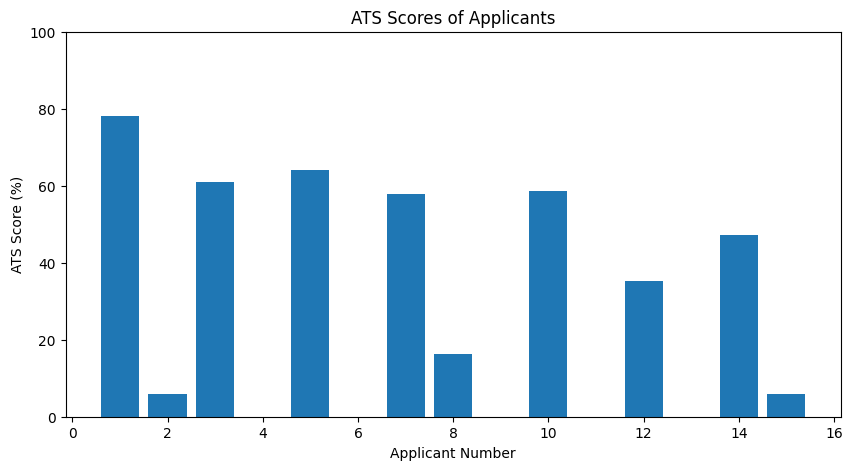

In [ ]:
plt.figure(figsize=(10,5))
plt.bar(
    range(1, len(df)+1),
    df["ATS_Score"]
)
plt.xlabel("Applicant Number")
plt.ylabel("ATS Score (%)")
plt.title("ATS Scores of Applicants")
plt.ylim(0,100)
plt.show()

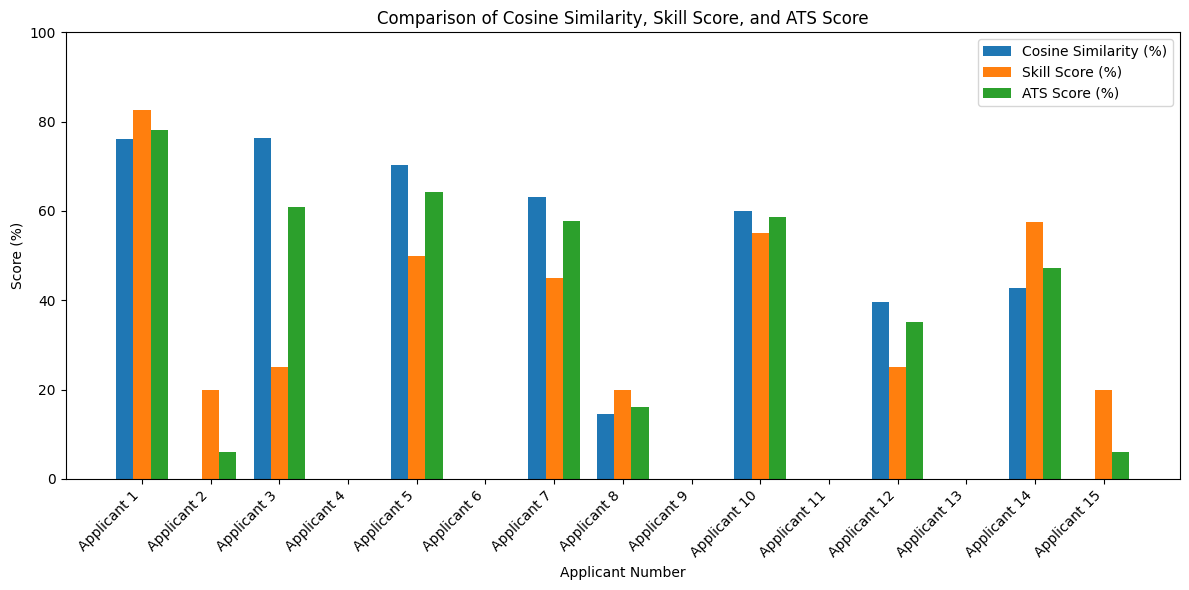

In [ ]:
import numpy as np
bar_width = 0.25
r = np.arange(len(df))
fig, ax = plt.subplots(figsize=(12, 6))
# Plot Cosine Similarity
bar1 = ax.bar(r - bar_width, df['Similarity_Percentage'], width=bar_width, label='Cosine Similarity (%)')
# Plot Skill Score
bar2 = ax.bar(r, df['Skill_Score'], width=bar_width, label='Skill Score (%)')
# Plot ATS Score
bar3 = ax.bar(r + bar_width, df['ATS_Score'], width=bar_width, label='ATS Score (%)')
ax.set_xlabel('Applicant Number')
ax.set_ylabel('Score (%)')
ax.set_title('Comparison of Cosine Similarity, Skill Score, and ATS Score')
ax.set_xticks(r)
ax.set_xticklabels([f'Applicant {i+1}' for i in range(len(df))])
ax.set_ylim(0, 100)
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

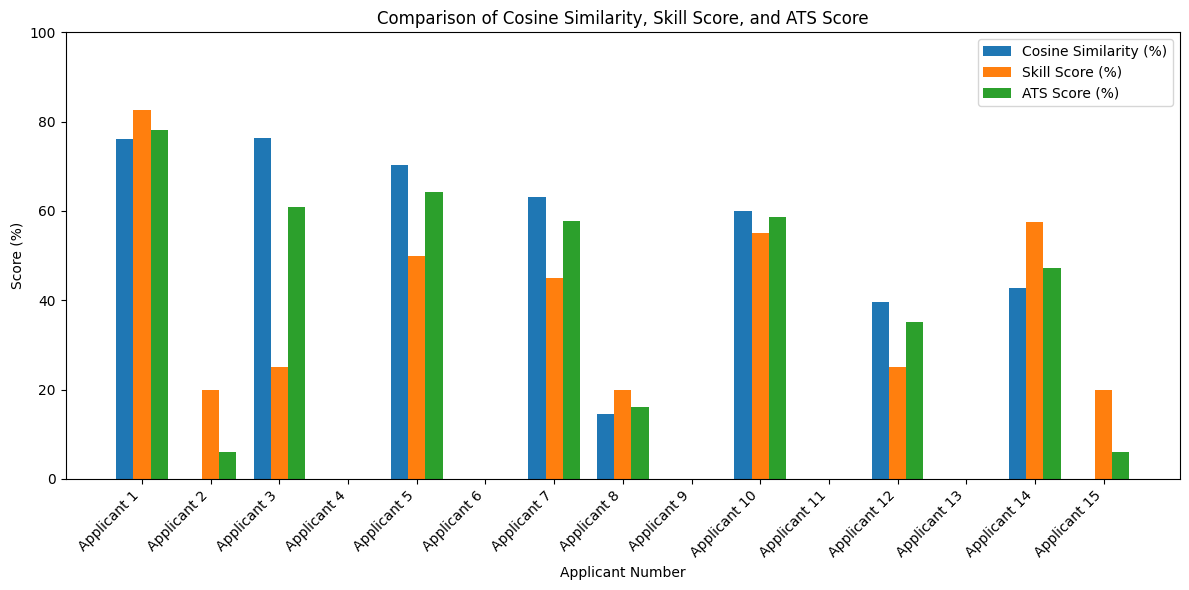

In [ ]:
import numpy as np
bar_width = 0.25
r = np.arange(len(df))
fig, ax = plt.subplots(figsize=(12, 6))
# Plot Cosine Similarity
bar1 = ax.bar(r - bar_width, df['Similarity_Percentage'], width=bar_width, label='Cosine Similarity (%)')
# Plot Skill Score
bar2 = ax.bar(r, df['Skill_Score'], width=bar_width, label='Skill Score (%)')
# Plot ATS Score
bar3 = ax.bar(r + bar_width, df['ATS_Score'], width=bar_width, label='ATS Score (%)')
ax.set_xlabel('Applicant Number')
ax.set_ylabel('Score (%)')
ax.set_title('Comparison of Cosine Similarity, Skill Score, and ATS Score')
ax.set_xticks(r)
ax.set_xticklabels([f'Applicant {i+1}' for i in range(len(df))])
ax.set_ylim(0, 100)
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#Display the Top Candidate

In [ ]:
best_index = df["ATS_Score"].idxmax()
print("========== BEST CANDIDATE ==========")
print(f"Applicant Number : {best_index + 1}")
print(f"ATS Score        : {df.loc[best_index, 'ATS_Score']:.2f}%")
print(f"Prediction       : {df.loc[best_index, 'Final_Prediction']}")

========== BEST CANDIDATE ==========
Applicant Number : 1
ATS Score        : 78.03%
Prediction       : Suitable


#Display the Complete Ranking

In [ ]:
ranking = df[["ATS_Score", "Final_Prediction"]].copy()
ranking["Applicant Number"] = range(1, len(df)+1)
ranking = ranking[[
    "Applicant Number",
    "ATS_Score",
    "Final_Prediction"
]]
ranking = ranking.sort_values(
    by="ATS_Score",
    ascending=False
)
ranking.reset_index(drop=True, inplace=True)
ranking

,Applicant Number,ATS_Score,Final_Prediction
0,1,78.03,Suitable
1,5,64.20,Suitable
2,3,60.92,Suitable
3,10,58.56,Suitable
4,7,57.76,Suitable
5,14,47.17,Not Suitable
6,12,35.18,Not Suitable
7,8,16.20,Not Suitable
8,15,6.00,Not Suitable
9,2,6.00,Not Suitable


#Final Prediction
Explanation

After calculating the ATS Score, the system decides whether an applicant is Suitable or Not Suitable.

For this project, we'll use a threshold of 75%:

ATS Score ≥ 50% → Suitable
ATS Score < 50% → Not Suitable

#Create the Prediction Function

In [ ]:
def predict_applicant(score):
    if score >= 50:
        return "Suitable"
    else:
        return "Not Suitable"

#Apply the Function

In [ ]:
df["Prediction"] = df["ATS_Score"].apply(predict_applicant)

#Display the Final Results

In [ ]:
df[[
    "Similarity_Percentage",
    "Skill_Score",
    "ATS_Score",
    "Prediction"
]]

,Similarity_Percentage,Skill_Score,ATS_Score,Prediction
0,76.12,82.5,78.03,Suitable
1,0.00,20.0,6.00,Not Suitable
2,76.31,25.0,60.92,Suitable
3,0.00,0.0,0.00,Not Suitable
4,70.28,50.0,64.20,Suitable
5,0.00,0.0,0.00,Not Suitable
6,63.23,45.0,57.76,Suitable
7,14.57,20.0,16.20,Not Suitable
8,0.00,0.0,0.00,Not Suitable
9,60.08,55.0,58.56,Suitable


#Display Every Applicant's Result

In [ ]:
for i in range(len(df)):
    print(f"Applicant Number : {i+1}")
    print(f"Similarity Score : {df.loc[i,'Similarity_Percentage']:.2f}%")
    print(f"Skill Score      : {df.loc[i,'Skill_Score']:.2f}%")
    print(f"ATS Score        : {df.loc[i,'ATS_Score']:.2f}%")
    print(f"Prediction       : {df.loc[i,'Prediction']}")
    print("-"*50)

Applicant Number : 1
Similarity Score : 76.12%
Skill Score      : 82.50%
ATS Score        : 78.03%
Prediction       : Suitable
--------------------------------------------------
Applicant Number : 2
Similarity Score : 0.00%
Skill Score      : 20.00%
ATS Score        : 6.00%
Prediction       : Not Suitable
--------------------------------------------------
Applicant Number : 3
Similarity Score : 76.31%
Skill Score      : 25.00%
ATS Score        : 60.92%
Prediction       : Suitable
--------------------------------------------------
Applicant Number : 4
Similarity Score : 0.00%
Skill Score      : 0.00%
ATS Score        : 0.00%
Prediction       : Not Suitable
--------------------------------------------------
Applicant Number : 5
Similarity Score : 70.28%
Skill Score      : 50.00%
ATS Score        : 64.20%
Prediction       : Suitable
--------------------------------------------------
Applicant Number : 6
Similarity Score : 0.00%
Skill Score      : 0.00%
ATS Score        : 0.00%
Prediction 

#Find the Best Applicant

In [ ]:
best_index = df["ATS_Score"].idxmax()
print("========== BEST APPLICANT ==========")
print(f"Applicant Number : {best_index + 1}")
print(f"ATS Score        : {df.loc[best_index,'ATS_Score']:.2f}%")
print(f"Prediction       : {df.loc[best_index,'Prediction']}")

========== BEST APPLICANT ==========
Applicant Number : 1
ATS Score        : 78.03%
Prediction       : Suitable


#Visualization 1: Bar Chart of ATS Scores

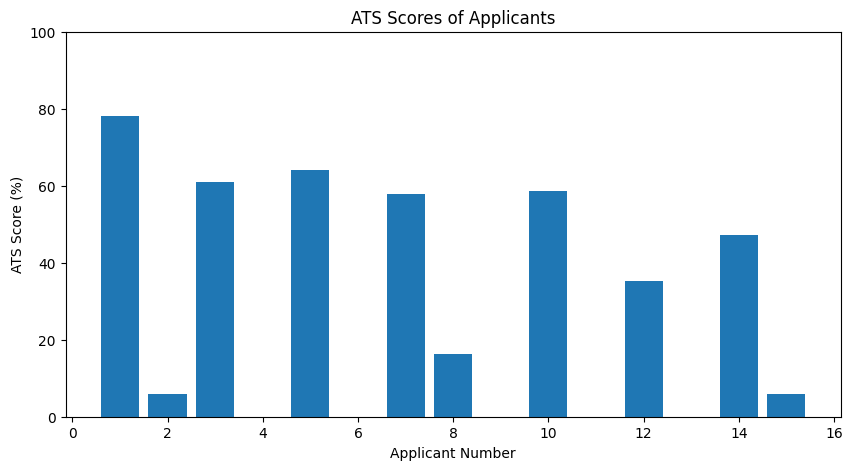

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.bar(
    range(1, len(df)+1),
    df["ATS_Score"]
)
plt.xlabel("Applicant Number")
plt.ylabel("ATS Score (%)")
plt.title("ATS Scores of Applicants")
plt.ylim(0,100)
plt.show()

#Visualization 2: Histogram of Similarity Scores
Explanation

A histogram shows how the similarity scores are distributed among all applicants.

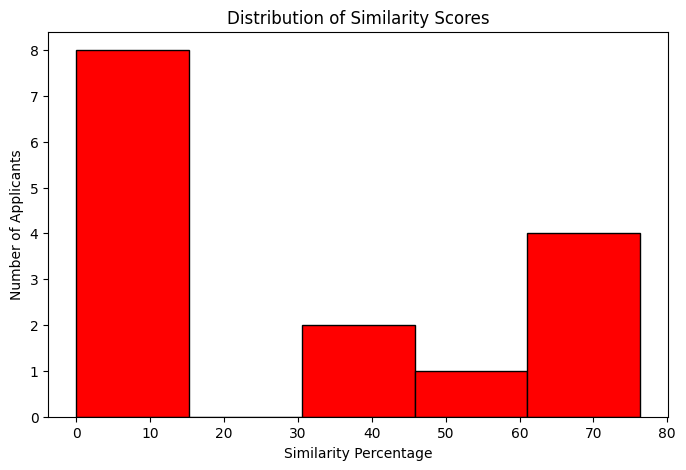

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(
    df["Similarity_Percentage"],
    bins=5,
    edgecolor="black",
    color="red"
)
plt.xlabel("Similarity Percentage")
plt.ylabel("Number of Applicants")
plt.title("Distribution of Similarity Scores")
plt.show()

#Visualization 3: Pie Chart (Suitable vs Not Suitable)

Count how many applicants are suitable and not suitable.

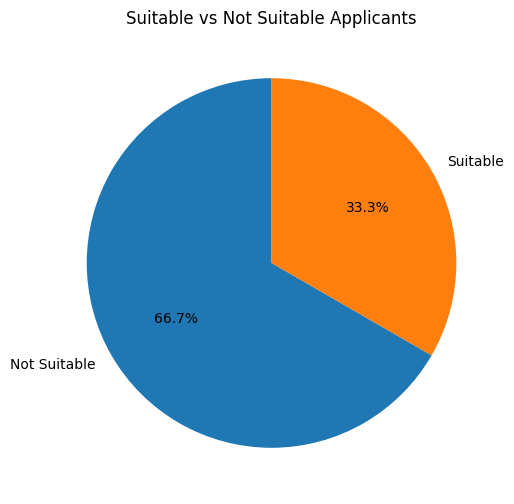

In [ ]:
prediction_counts = df["Prediction"].value_counts()
plt.figure(figsize=(6,6))
plt.pie(
    prediction_counts,
    labels=prediction_counts.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Suitable vs Not Suitable Applicants")
plt.show()

#Visualization 4: Pie Chart (Matched Skills vs Missing Skills)

First define the company's required skills.

In [ ]:
job_skills = {
    "python":10,
    "sql":8,
    "machine learning":10,
    "git":5,
    "docker":7
}

Now check the best applicant.

In [ ]:
best_index = df["ATS_Score"].idxmax()
resume = df.loc[best_index, "Clean_Resume"]
matched = 0
missing = 0
for skill in job_skills:
    if skill in resume:
        matched += 1
    else:
        missing += 1

Create the pie chart.

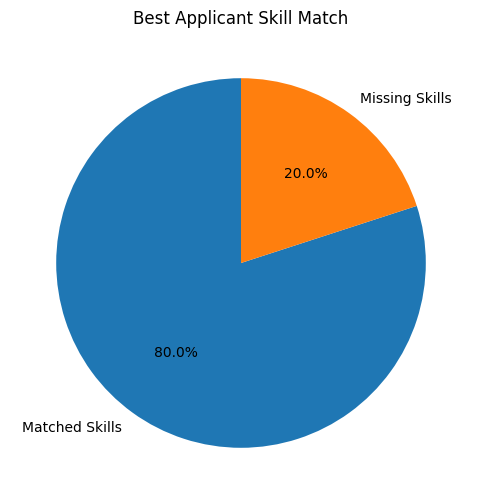

In [ ]:
plt.figure(figsize=(6,6))
plt.pie(
    [matched, missing],
    labels=["Matched Skills", "Missing Skills"],
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Best Applicant Skill Match")
plt.show()

#Visualization 5: Top 5 Applicants

Sort applicants by ATS score.

In [ ]:
top5 = df.sort_values(
    by="ATS_Score",
    ascending=False
).head(5)

top5 score

In [ ]:
top5['ATS_Score']

,ATS_Score
0,78.03
4,64.20
2,60.92
9,58.56
6,57.76


Plot the top 5.

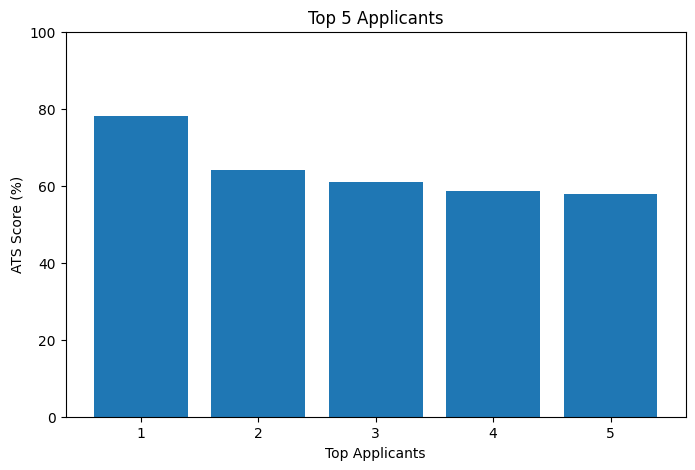

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(
    range(1, len(top5)+1),
    top5["ATS_Score"]
)
plt.xlabel("Top Applicants")
plt.ylabel("ATS Score (%)")
plt.title("Top 5 Applicants")
plt.xticks(range(1,6))
plt.ylim(0,100)
plt.show()

#Save the TF-IDF Vectorizer and ATS Results

#Import Joblib

In [ ]:
import joblib

#Save the Vectorizer

In [ ]:
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")
print("Vectorizer saved successfully!")

Vectorizer saved successfully!


#Verify It Works

In [ ]:
loaded_vectorizer = joblib.load("tfidf_vectorizer.pkl")
print(type(loaded_vectorizer))

<class 'sklearn.feature_extraction.text.TfidfVectorizer'>


#Download the Vectorizer (Google Colab)

In [ ]:
from google.colab import files
files.download("tfidf_vectorizer.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#Save the Results

Save the results of your ATS screening.

In [ ]:
df.to_csv("ATS_Result.csv", index=False)
print("ATS results saved successfully!")

ATS results saved successfully!


#Download the CSV

In [ ]:
files.download("ATS_Result.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#Files Produced

After completing the notebook, you'll have:

resume_dataset.csv        ← Input dataset

ATS_Result.csv            ← Final ATS results

tfidf_vectorizer.pkl      ← TF-IDF Vectorizer